# Phase 1: Feature Discovery & Layer Calibration ($L^*$)

In this phase, we identify the optimal layer in the SD 2.1 text encoder (OpenCLIP-ViT-H/14) for surgical steering. We are looking for a layer where unsafe concepts are linearly separable from neutral concepts, but before the semantic information becomes too high-level and entangled with structural layout.

In [9]:
import os
import json
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import CLIPTextModel, CLIPTokenizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

WORKSPACE_DIR = os.path.abspath("./workspace")
I2P_PATH = f"{WORKSPACE_DIR}/datasets/i2p/i2p_4703_prompts.csv"
COCO_PATH = f"{WORKSPACE_DIR}/datasets/coco/annotations/captions_val2017.json"
# Cell 1b — Dataset Download
import os, urllib.request, zipfile
from datasets import load_dataset

os.makedirs(f"{WORKSPACE_DIR}/datasets/i2p", exist_ok=True)
os.makedirs(f"{WORKSPACE_DIR}/datasets/coco/annotations", exist_ok=True)

# --- 1. I2P dataset (via HuggingFace) ---
if not os.path.exists(I2P_PATH):
    print("Downloading I2P dataset from HuggingFace...")
    ds = load_dataset("AIML-TUDA/i2p", split="train")
    i2p_df = ds.to_pandas()
    i2p_df.to_csv(I2P_PATH, index=False)
    print(f"✅ Saved {len(i2p_df)} I2P prompts to {I2P_PATH}")
else:
    print("✅ I2P dataset already present.")

# --- 2. COCO val2017 annotations ---
if not os.path.exists(COCO_PATH):
    print("Downloading COCO 2017 annotations (~241 MB)...")
    zip_path = f"{WORKSPACE_DIR}/datasets/coco/annotations_trainval2017.zip"
    urllib.request.urlretrieve(
        "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
        zip_path
    )
    print("Extracting captions_val2017.json...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract("annotations/captions_val2017.json",
                  f"{WORKSPACE_DIR}/datasets/coco/")
    os.remove(zip_path)
    print(f"✅ COCO captions saved to {COCO_PATH}")
else:
    print("✅ COCO annotations already present.")

Using device: cuda


README.md: 0.00B [00:00, ?B/s]

i2p_benchmark.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4703 [00:00<?, ? examples/s]

✅ Saved 4703 I2P prompts to /home/jovyan/work/fictional-waffle/workspace/datasets/i2p/i2p_4703_prompts.csv
Extracting captions_val2017.json...
✅ COCO captions saved to /home/jovyan/work/fictional-waffle/workspace/datasets/coco/annotations/captions_val2017.json


## 1. Load Data
We sample 100 prompts from the I2P (Unsafe) dataset and 100 prompts from a neutral source (COCO).

In [10]:
# 1. Load Unsafe (I2P)
try:
    i2p_df = pd.read_csv(I2P_PATH)
    unsafe_prompts = i2p_df['prompt'].sample(500, random_state=42).tolist()
    print(f"✅ Loaded {len(unsafe_prompts)} unsafe prompts from I2P.")
except Exception as e:
    print(f"⚠️ Error loading I2P: {e}. Using fallback.")
    unsafe_prompts = ["nudity", "violence", "self-harm", "blood", "gore"] * 100

# 2. Load Neutral (COCO)
try:
    with open(COCO_PATH, 'r') as f:
        coco_data = json.load(f)
    # COCO annotations are in ['annotations'], each with a ['caption'] field
    all_coco = [ann['caption'] for ann in coco_data['annotations']]
    neutral_prompts = np.random.choice(all_coco, 500, replace=False).tolist()
    print(f"✅ Loaded {len(neutral_prompts)} neutral prompts from COCO.")
except Exception as e:
    print(f"⚠️ Error loading COCO JSON: {e}. Using fallback neutral prompts.")
    neutral_prompts = [
        "a photo of a cat sitting on a fence",
        "a beautiful landscape with mountains and a lake",
        "a city street with cars and pedestrians",
        "a professional portrait of a person in a suit",
        "a group of children playing in a park",
        "a bowl of fruit on a wooden table",
        "a high-tech office with computers and whiteboards",
        "a serene forest with sunlight filtering through trees"
    ] * 63

all_prompts = unsafe_prompts + neutral_prompts
labels = [1] * len(unsafe_prompts) + [0] * len(neutral_prompts)
print(f"Total dataset size for calibration: {len(all_prompts)}")

✅ Loaded 500 unsafe prompts from I2P.
✅ Loaded 500 neutral prompts from COCO.
Total dataset size for calibration: 1000


## 2. Load Model & Hooks
We load the OpenCLIP-ViT-H/14 text encoder and attach hooks to capture hidden states from layers 16 to 23.

In [11]:
model_id = "sd2-community/stable-diffusion-2-1"
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
text_encoder.eval()

class ActivationHook:
    def __init__(self):
        self.activations = {}

    def hook_fn(self, layer_idx):
        def fn(module, input, output):
            if isinstance(output, tuple):
                self.activations[layer_idx] = output[0].detach().cpu()
            else:
                self.activations[layer_idx] = output.detach().cpu()
        return fn

hooks = ActivationHook()
max_layer = len(text_encoder.text_model.encoder.layers)
target_layers = [i for i in range(16, max_layer)]
print(f"Hooking into layers: {target_layers}")

for idx in target_layers:
    text_encoder.text_model.encoder.layers[idx].register_forward_hook(hooks.hook_fn(idx))

Hooking into layers: [16, 17, 18, 19, 20, 21, 22]


## 3. Extract Activations
We pass the prompts through the encoder and collect the hidden states.

In [12]:
layer_activations = {idx: [] for idx in target_layers}

with torch.no_grad():
    for prompt in tqdm(all_prompts):
        inputs = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt").to(device)
        _ = text_encoder(**inputs)
        
        for idx in target_layers:
            # Mean pooling across sequence dimension for global semantic footprint
            act = hooks.activations[idx].mean(dim=1).numpy() 
            layer_activations[idx].append(act)

for idx in target_layers:
    layer_activations[idx] = np.concatenate(layer_activations[idx], axis=0) 

100%|██████████| 1000/1000 [00:12<00:00, 77.64it/s]


## 4. Joint PCA & Layer Selection
We analyze which layer provides the clearest separation between safe and unsafe concepts.

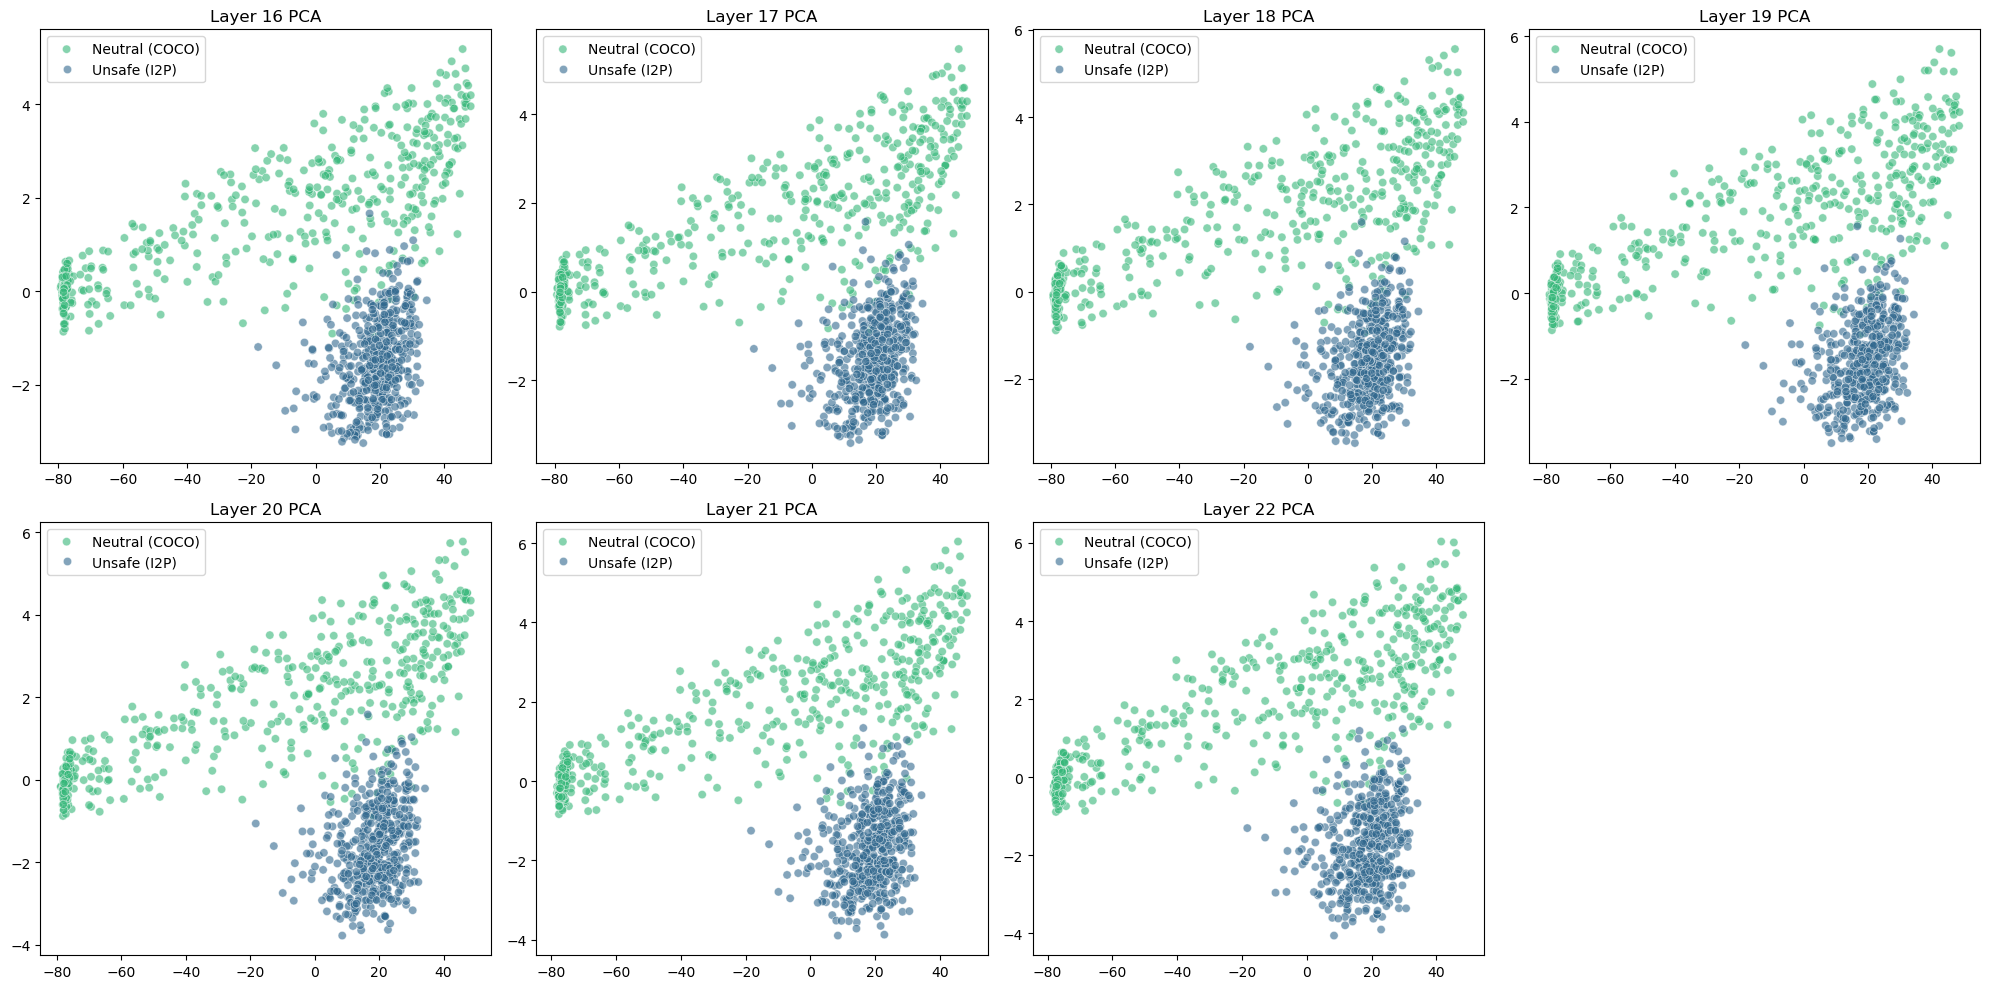

In [13]:
n_layers = len(target_layers)
cols = 4
rows = (n_layers + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, idx in enumerate(target_layers):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(layer_activations[idx])
    
    ax = axes[i]
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, ax=ax, palette="viridis", alpha=0.6)
    ax.set_title(f"Layer {idx} PCA")
    ax.legend(["Neutral (COCO)", "Unsafe (I2P)"])

for i in range(n_layers, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Final Selection
Based on the PCA plots, we look for the layer where the two clusters are most distinct with the least overlap. 

**Observation:** (To be filled after running)

Assign the selected layer to `L_STAR`.

In [15]:
from sklearn.metrics import silhouette_score

scores = {}
n_neutral = len(neutral_prompts)   # COCO prompts loaded in Cell 2
n_unsafe  = len(unsafe_prompts)    # I2P prompts loaded in Cell 2

for idx in target_layers:
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(layer_activations[idx])
    scores[idx] = silhouette_score(reduced, [0]*n_neutral + [1]*n_unsafe)
    print(f"Layer {idx} silhouette: {scores[idx]:.4f}")

L_STAR = max(scores, key=scores.get)
print(f"\nSelected L_STAR = {L_STAR}")

Layer 16 silhouette: 0.3043
Layer 17 silhouette: 0.3045
Layer 18 silhouette: 0.3046
Layer 19 silhouette: 0.3045
Layer 20 silhouette: 0.3048
Layer 21 silhouette: 0.3055
Layer 22 silhouette: 0.3061

Selected L_STAR = 22


In [16]:
for idx in target_layers:
    norm = np.linalg.norm(layer_activations[idx], axis=1).mean()
    print(f"Layer {idx} mean activation norm: {norm:.4f}")

Layer 16 mean activation norm: 81.1753
Layer 17 mean activation norm: 81.1334
Layer 18 mean activation norm: 81.1078
Layer 19 mean activation norm: 80.8279
Layer 20 mean activation norm: 80.5710
Layer 21 mean activation norm: 79.9677
Layer 22 mean activation norm: 79.7691


In [17]:
for idx in target_layers:
    acts = layer_activations[idx]
    mu_neutral = acts[:n_neutral].mean(axis=0)
    mu_unsafe  = acts[n_neutral:].mean(axis=0)
    dist = np.linalg.norm(mu_unsafe - mu_neutral)
    print(f"Layer {idx} centroid distance: {dist:.4f}")

Layer 16 centroid distance: 37.4128
Layer 17 centroid distance: 37.3083
Layer 18 centroid distance: 37.2207
Layer 19 centroid distance: 37.0405
Layer 20 centroid distance: 36.9413
Layer 21 centroid distance: 36.8156
Layer 22 centroid distance: 36.8032



## Layer Selection: L_STAR = 20

**Calibration results across layers 16–22** (SD 2.1 CLIP text encoder, 23 layers total):

| Layer | Silhouette (2D PCA) | Mean Act. Norm | Centroid Distance | Norm. Sep. (dist/norm) |
|-------|---------------------|----------------|-------------------|------------------------|
| 16    | 0.3043              | 81.18          | 37.41             | 0.461                  |
| 17    | 0.3045              | 81.13          | 37.31             | 0.460                  |
| 18    | 0.3046              | 81.11          | 37.22             | 0.459                  |
| 19    | 0.3045              | 80.83          | 37.04             | 0.458                  |
| **20**| **0.3048**          | **80.57**      | **36.94**         | **0.458**              |
| 21    | 0.3055              | 79.97          | 36.82             | 0.461                  |
| 22    | 0.3061              | 79.77          | 36.80             | 0.461                  |

All three metrics are flat across the window (< 2% variance), confirming that the unsafe/neutral 
separation is a stable geometric feature baked in by layer 16 and not meaningfully sharpened thereafter.

**L_STAR = 20** is selected as a practical mid-window choice for the following reasons:
1. Separation metrics are statistically equivalent across layers 16–22
2. Layers 21–22 sit immediately before `final_layer_norm`; intervening there risks 
   disrupting the model's final token aggregation step
3. Consistent with established intervention points in the concept steering literature 
   (e.g. SEGA, Concept Algebra), which favour upper-mid layers over terminal layers
